# Seção de Resultados — Tabelas e Figuras

Gera todas as tabelas e figuras usadas na seção de resultados do TCC, a partir
dos artefatos já salvos em `experiments/` e `data/images/datasets/`
(nenhum modelo é re-treinado aqui — apenas leitura, agregação e plotagem).

Tabelas:
1. Top 5 modelos por dataset (Trilha A e B) — AUC mean ± std no k-fold
2. Resultados finais no teste — thr=0.5 e Youden, comparativo Trilha A vs B
3. Top features por ANOVA e MI — top-10 por dataset

Figuras:
1. AUC boxplot dos top 5 modelos por trilha e dataset (k-fold) — `task5_auc_boxplot.png`
2. AUC por valor de K no k-sweep — `k_sweep_auc_line.png`
3. Matrizes de confusão dos modelos finais (Trilha A e B) — `test_confusion_matrices.png`
4. Comparação sensibilidade/especificidade — `test_sens_spec_comparison.png`
5. Sobreposição do ranking de features (ANOVA vs MI) — `task7a_kbest_overlap.png`
6. Curva de dispersão dos scores SelectKBest por dataset (ANOVA vs MI) — `task7a_kbest_score_curves.png`


## Env Configuration

Importações, caminhos dos artefatos de entrada (Trilha A/B, k-sweep, k-best) e
diretório de saída das tabelas/figuras da seção de resultados.

In [ ]:
import os
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'images', 'datasets')
MODULES_DIR  = os.path.join(PROJECT_ROOT, 'modules')

TRILHA_A_DIR       = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_a')
TRILHA_A_FINAL_DIR = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_a_final')
TRILHA_A_SWEEP_DIR = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_a_k_sweep')
TRILHA_B_DIR       = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_b')
TRILHA_B_FINAL_DIR = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_b_final')

OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'experiments', 'resultados_secao')
os.makedirs(OUTPUT_DIR, exist_ok=True)

if MODULES_DIR not in sys.path:
    sys.path.insert(0, MODULES_DIR)

from evaluation import (
    DATASETS, DS_COLORS,
    select_top_models,
    plot_auc_boxplot,
    build_top5_comparison_table,
    build_test_results_comparison_table,
    build_kbest_top_features_table,
    plot_test_confusion_matrices,
    plot_test_sens_spec_comparison,
    plot_k_sweep_auc_line,
    plot_kbest_overlap,
    plot_kbest_score_curves,
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 9

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'OUTPUT_DIR   : {OUTPUT_DIR}')

## Functions

Carregamento dos artefatos (CSVs de métricas agregadas, resultados de teste,
k-sweep e ranking de features) usados para montar as tabelas e figuras.

In [7]:
def load_results_artifacts():
    """Carrega todos os CSVs de Trilha A/B, k-sweep e k-best em um dict único."""
    return {
        # 'agg_a':      pd.read_csv(os.path.join(TRILHA_A_DIR, 'task4_aggregated_metrics.csv')),
        # 'agg_b':      pd.read_csv(os.path.join(TRILHA_B_DIR, 'task4_aggregated_metrics.csv')),
        'folds_a':    pd.read_csv(os.path.join(TRILHA_A_DIR, 'task3_fold_metrics.csv')),
        'folds_b':    pd.read_csv(os.path.join(TRILHA_B_DIR, 'task3_fold_metrics.csv')),
        'top5_a':     pd.read_csv(os.path.join(TRILHA_A_DIR, 'task5_top_models.csv')),
        'top5_b':     pd.read_csv(os.path.join(TRILHA_B_DIR, 'task5_top_models.csv')),
        'test_a':     pd.read_csv(os.path.join(TRILHA_A_FINAL_DIR, 'test_results.csv')),
        'test_b':     pd.read_csv(os.path.join(TRILHA_B_FINAL_DIR, 'test_results.csv')),
        'k_sweep':    pd.read_csv(os.path.join(TRILHA_A_SWEEP_DIR, 'k_sweep_results.csv')),
        'kbest':      pd.read_csv(os.path.join(DATA_DIR, 'task7a_kbest_rankings.csv')),
    }

## Process

Carrega os artefatos e, em sequência, gera cada tabela (salva como CSV em
`experiments/resultados_secao/`) e cada figura (PNG) listadas na introdução.

### 1. Carga dos artefatos

In [8]:
artifacts = load_results_artifacts()
for name, df in artifacts.items():
    print(f'{name:10s}: {df.shape}')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a/task3_fold_metrics.csv'

### 2. Tabela — Top 5 modelos por dataset (Trilha A e B)

AUC médio ± desvio-padrão no k-fold, recalculado a partir das métricas
agregadas (`task4_aggregated_metrics.csv`) com `select_top_models`.

In [5]:
df_top5_a = select_top_models(artifacts['agg_a'], top_n=5)
df_top5_b = select_top_models(artifacts['agg_b'], top_n=5)

table_top5 = build_top5_comparison_table(artifacts['agg_a'], artifacts['agg_b'], top_n=5)
out_csv = os.path.join(OUTPUT_DIR, 'table_top5_models_by_dataset.csv')
table_top5.to_csv(out_csv, index=False)
print(f'Salvo: {out_csv}')
table_top5

NameError: name 'artifacts' is not defined

### 3. Tabela — Resultados finais no teste (Trilha A vs B)

Tabela única comparativa com as métricas de teste (AUC, acurácia,
sensibilidade, especificidade, F1) nos thresholds 0.5 e Youden, para as três
configurações de dataset (BW, Doppler, BW+Doppler).

In [6]:
table_test_results = build_test_results_comparison_table(artifacts['test_a'], artifacts['test_b'])
out_csv = os.path.join(OUTPUT_DIR, 'table_test_results_comparison.csv')
table_test_results.to_csv(out_csv, index=False)
print(f'Salvo: {out_csv}')
table_test_results

NameError: name 'artifacts' is not defined

### 4. Tabela — Top features por ANOVA e MI

Top-10 features por dataset e por critério de seleção (F-Score/ANOVA e
Mutual Information), a partir do ranking gerado em `kbest_analysis`.

In [ ]:
table_kbest_top = build_kbest_top_features_table(artifacts['kbest'], top_n=10)
out_csv = os.path.join(OUTPUT_DIR, 'table_kbest_top_features.csv')
table_kbest_top.to_csv(out_csv, index=False)
print(f'Salvo: {out_csv}')
table_kbest_top.head(20)

Salvo: C:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\resultados_secao\table_kbest_top_features.csv


,dataset,criterion,rank,feature_short,score
0,BW,F-Score (ANOVA),1,wavelet-LH_glrlm_GrayLevelNonUniformityNormalized,31.864918
1,BW,F-Score (ANOVA),2,wavelet-LH_firstorder_Entropy,30.667761
2,BW,F-Score (ANOVA),3,wavelet-LH_firstorder_Uniformity,30.397053
3,BW,F-Score (ANOVA),4,wavelet-LH_glcm_SumEntropy,29.932238
4,BW,F-Score (ANOVA),5,wavelet-LH_glcm_JointEntropy,29.771131
5,BW,F-Score (ANOVA),6,wavelet-LL_firstorder_10Percentile,28.483831
6,BW,F-Score (ANOVA),7,wavelet-LH_glrlm_ShortRunEmphasis,28.374036
7,BW,F-Score (ANOVA),8,original_firstorder_10Percentile,28.330873
8,BW,F-Score (ANOVA),9,wavelet-LL_ngtdm_Coarseness,28.124339
9,BW,F-Score (ANOVA),10,wavelet-LH_glcm_ClusterTendency,27.926709


### 5. Figura — AUC boxplot dos top 5 modelos (k-fold)

Distribuição do AUC por fold para os top-5 modelos de cada dataset, uma
figura por trilha (`task5_auc_boxplot.png`).

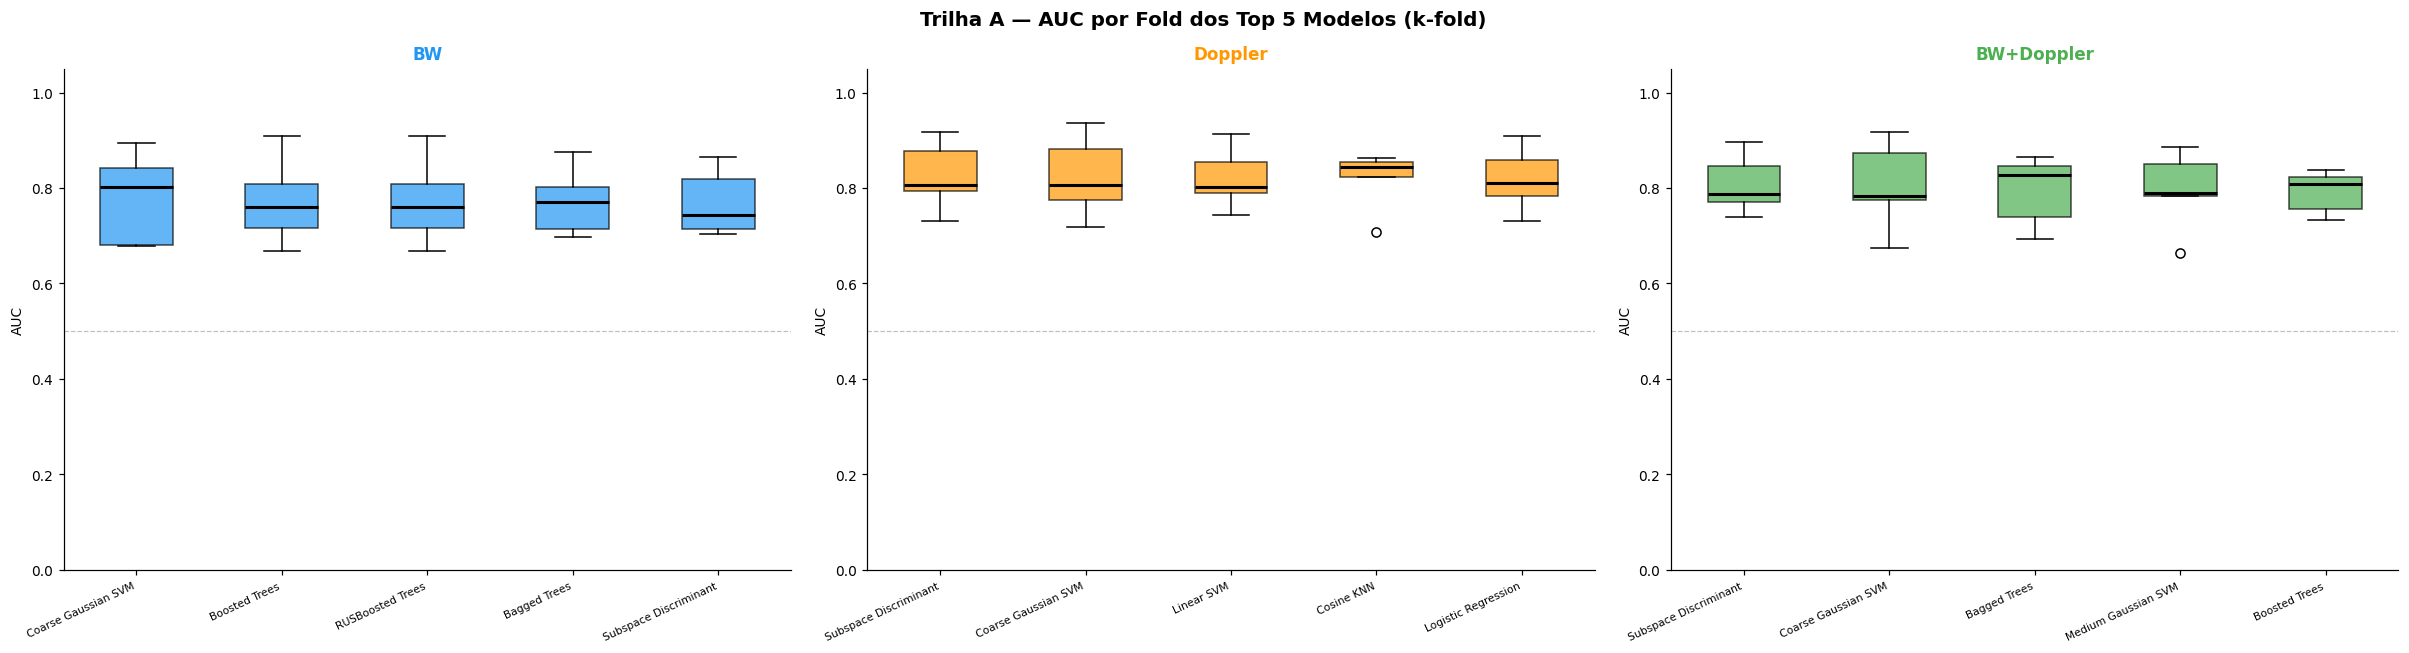

Salvo: C:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\resultados_secao\trilha_a_task5_auc_boxplot.png


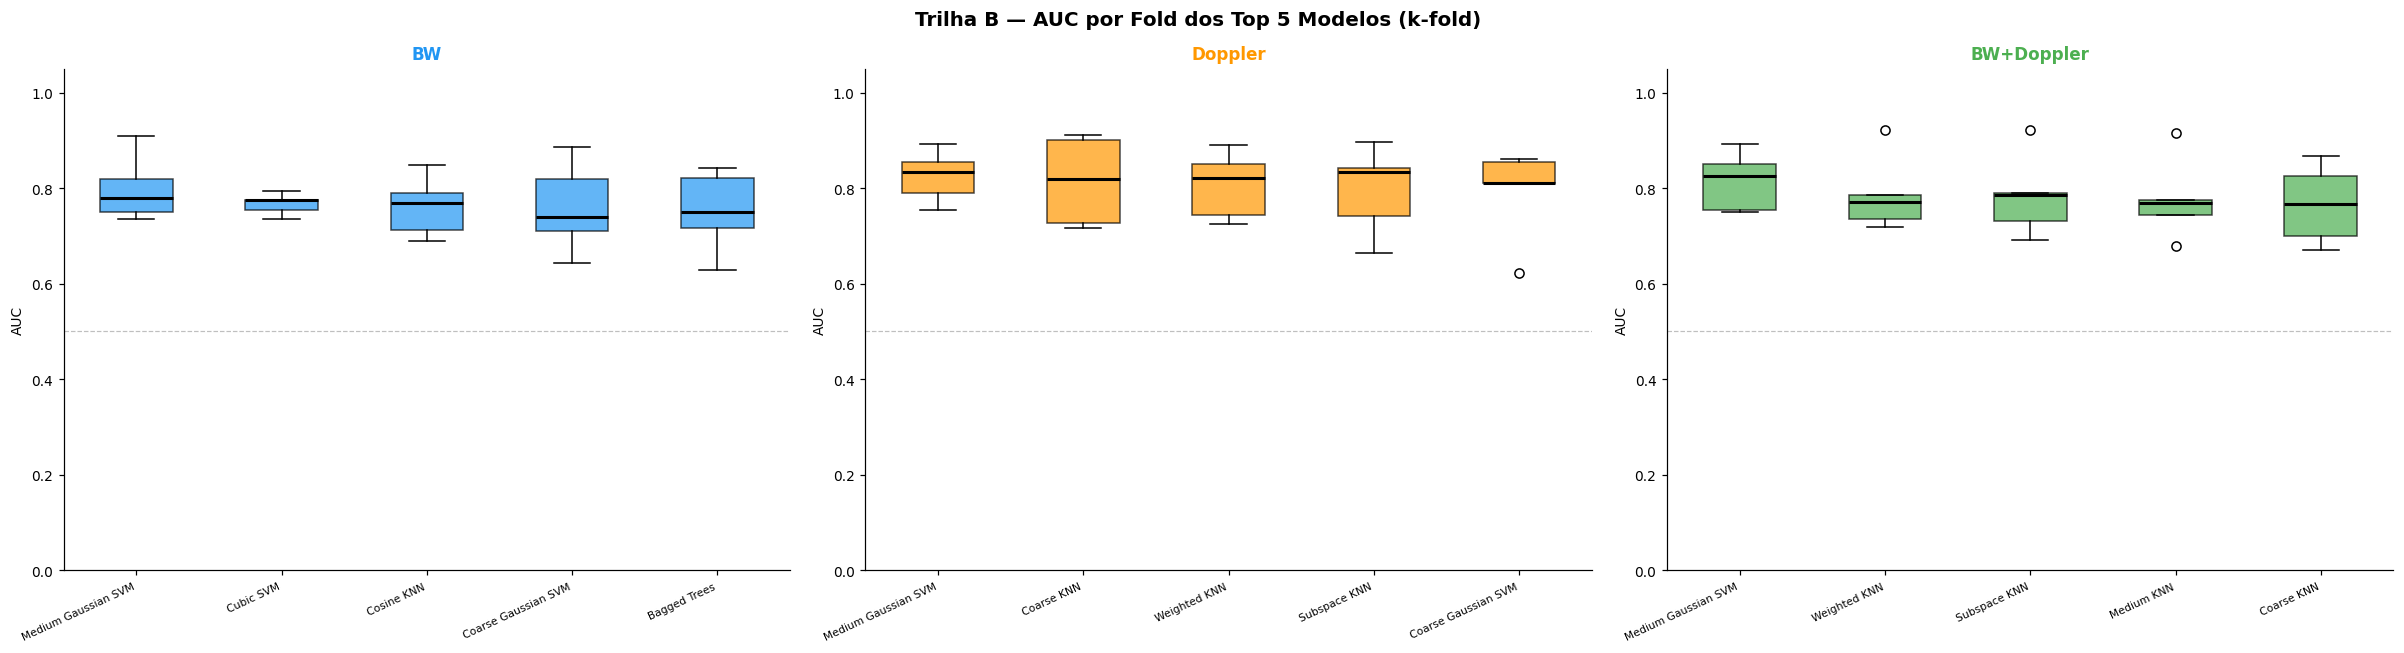

Salvo: C:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\resultados_secao\trilha_b_task5_auc_boxplot.png


In [ ]:
plot_auc_boxplot(
    artifacts['folds_a'], df_top5_a, top_n=5,
    output_path=os.path.join(OUTPUT_DIR, 'trilha_a_task5_auc_boxplot.png'),
    title='Trilha A — AUC por Fold dos Top 5 Modelos (k-fold)',
)

plot_auc_boxplot(
    artifacts['folds_b'], df_top5_b, top_n=5,
    output_path=os.path.join(OUTPUT_DIR, 'trilha_b_task5_auc_boxplot.png'),
    title='Trilha B — AUC por Fold dos Top 5 Modelos (k-fold)',
)

### 6. Figura — AUC por valor de K no k-sweep

Evolução do AUC no teste conforme o número de features selecionadas (K)
varia, uma linha por dataset, com o melhor modelo anotado em cada ponto
(`k_sweep_auc_line.png`).

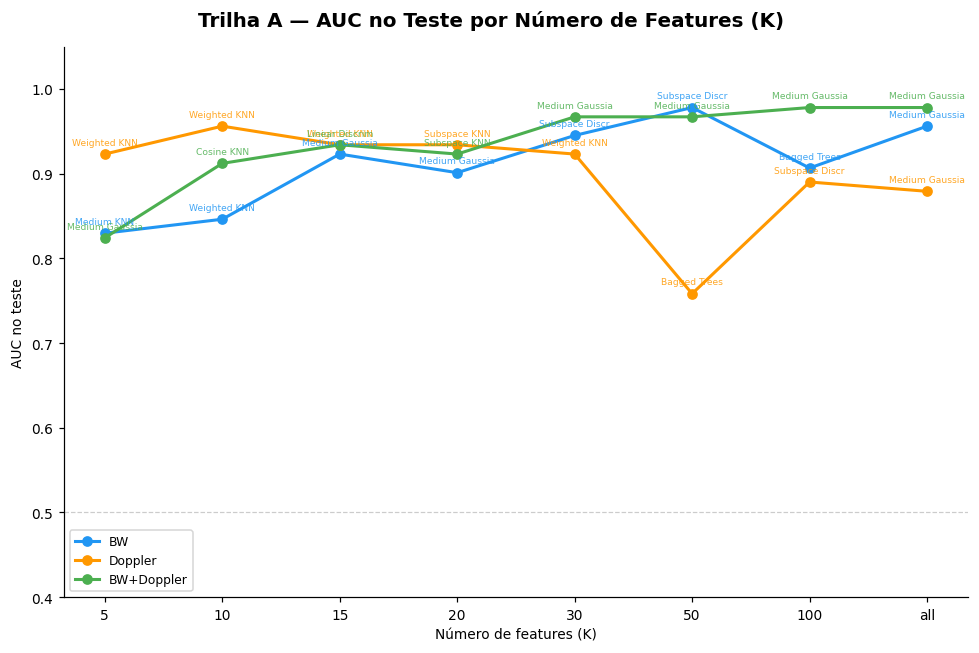

Salvo: C:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\resultados_secao\k_sweep_auc_line.png


In [ ]:
plot_k_sweep_auc_line(
    artifacts['k_sweep'],
    output_path=os.path.join(OUTPUT_DIR, 'k_sweep_auc_line.png'),
)

### 7. Figura — Matrizes de confusão no teste (Trilha A vs B)

Matrizes de confusão normalizadas por classe real, para o melhor modelo de
cada dataset em cada trilha, no threshold padrão (0.5). Reconstruídas a
partir das contagens (`test_tn/fp/fn/tp_05`) já salvas em `test_results.csv`
(`test_confusion_matrices.png`).

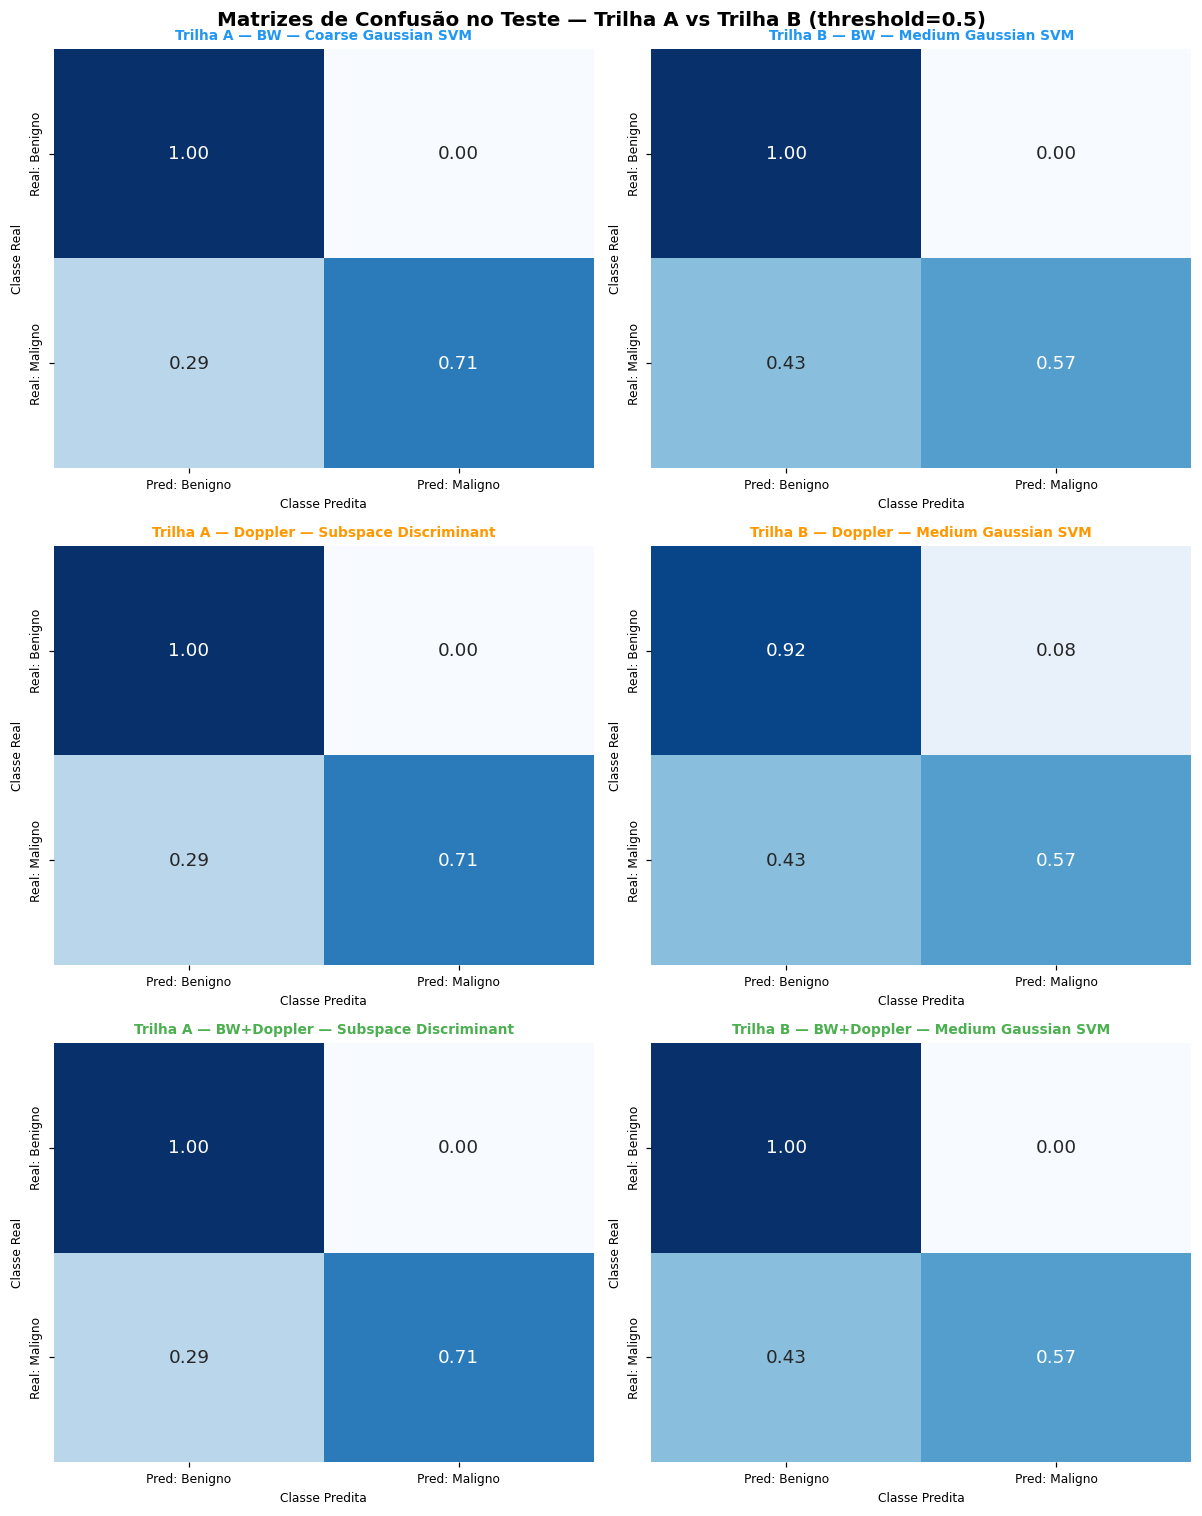

Salvo: C:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\resultados_secao\test_confusion_matrices.png


In [ ]:
plot_test_confusion_matrices(
    artifacts['test_a'], artifacts['test_b'],
    output_path=os.path.join(OUTPUT_DIR, 'test_confusion_matrices.png'),
)

### 8. Figura — Comparação sensibilidade/especificidade no teste

Sensibilidade e especificidade (threshold=0.5) lado a lado para Trilha A vs
Trilha B, por dataset (`test_sens_spec_comparison.png`).

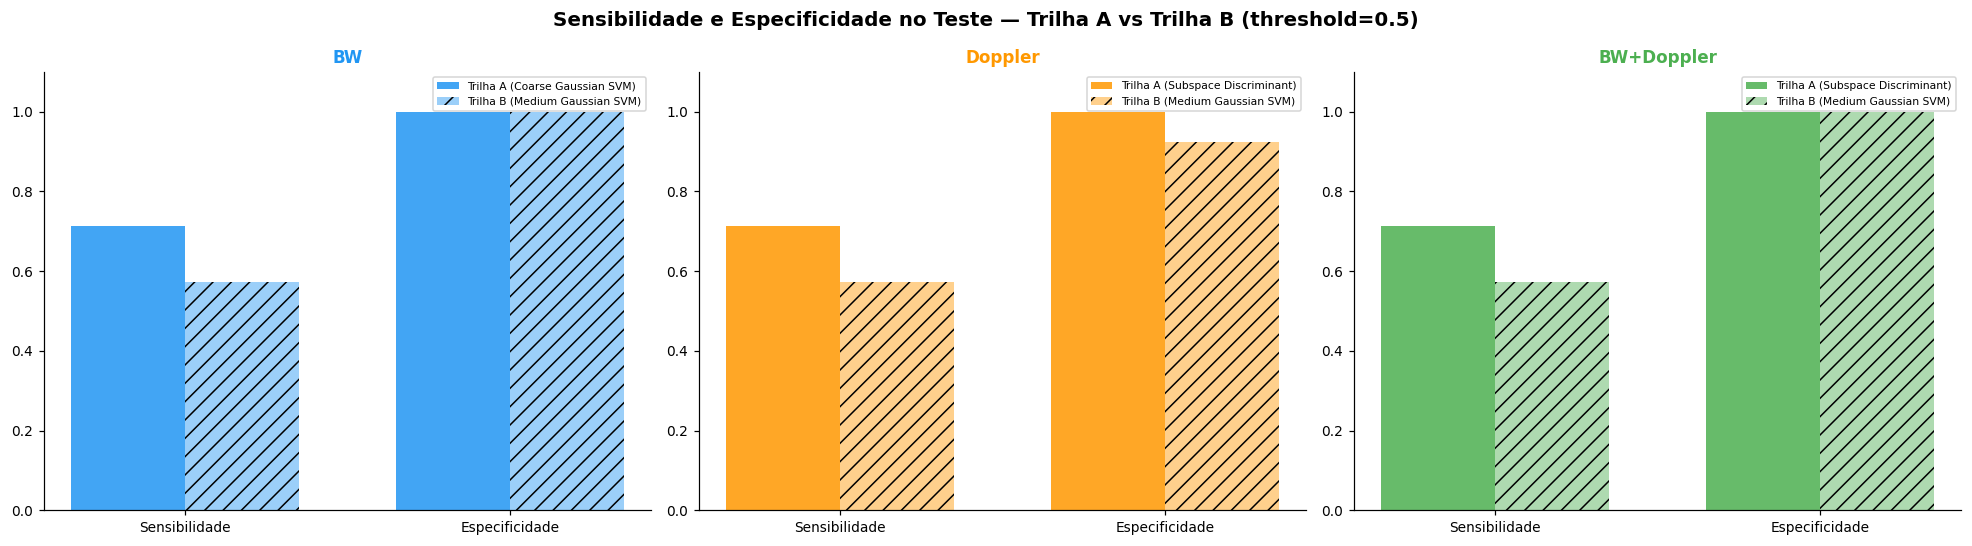

Salvo: C:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\resultados_secao\test_sens_spec_comparison.png


In [ ]:
plot_test_sens_spec_comparison(
    artifacts['test_a'], artifacts['test_b'],
    output_path=os.path.join(OUTPUT_DIR, 'test_sens_spec_comparison.png'),
)

### 9. Figura — Sobreposição do ranking de features (ANOVA vs MI)

Heatmap mostrando, para cada dataset, quantas das top-20 features
selecionadas por ANOVA (F-Score) também aparecem no top-20 por Mutual
Information (`task7a_kbest_overlap.png`).

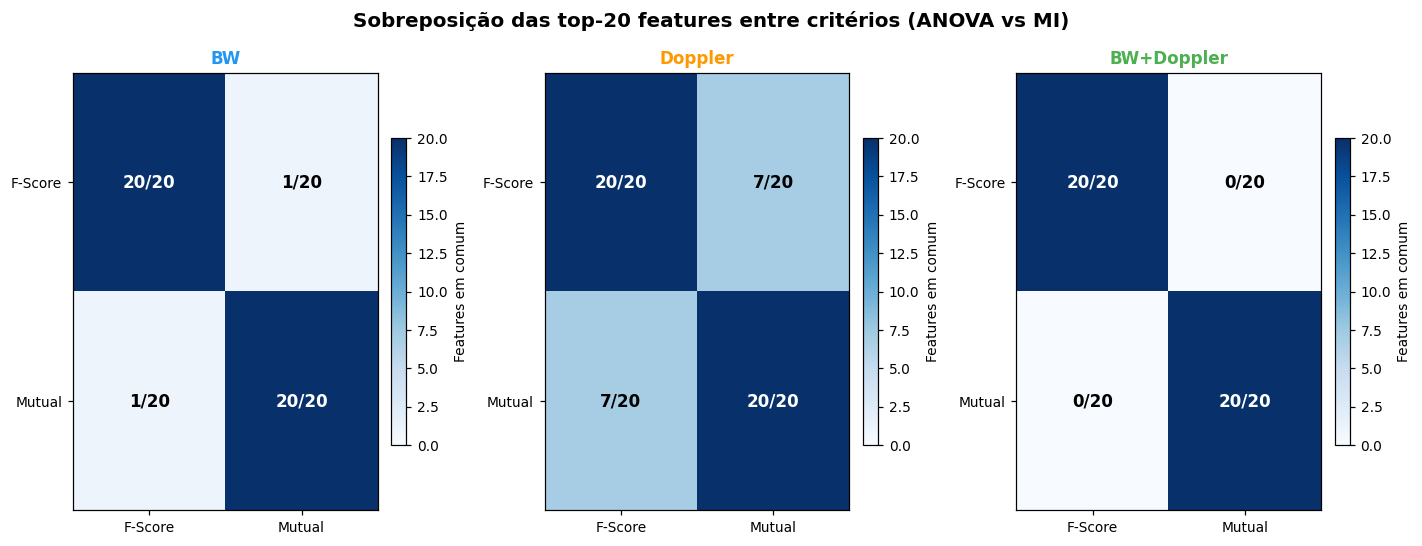

Salvo: C:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\resultados_secao\task7a_kbest_overlap.png


In [ ]:
plot_kbest_overlap(
    artifacts['kbest'],
    output_path=os.path.join(OUTPUT_DIR, 'task7a_kbest_overlap.png'),
    top_n=20,
)

### 10. Figura — Curva de dispersão dos scores SelectKBest

Curva de dispersão (score vs. posição no ranking) por dataset, equivalente
"em curva" aos gráficos de barra de `kbest_analysis`, um painel por critério
(ANOVA/MI) (`task7a_kbest_score_curves.png`).

In [ ]:
plot_kbest_score_curves(
    artifacts['kbest'],
    output_path=os.path.join(OUTPUT_DIR, 'task7a_kbest_score_curves.png'),
)